# xarray for OME-Zarr: greatest hits

Named dimensions, physical-unit selection, lazy multiscale pyramids, one-line analysis — and
the harder geometry (lens distortion, mosaic stitching, deskew) all expressed as **xarray
coordinates you can `.sel` on**.

1. `bioio` → xarray (any format) &nbsp; 2. named dims + physical `.sel` &nbsp; 3. lazy pyramids &nbsp; 4. analysis in one line &nbsp; 5. lens distortion &nbsp; 6. mosaic reassembly &nbsp; 7. deskew (exact inverse)

> **Environment.** Core demos need `xarray-ngff` + `matplotlib` + `scipy`. The `bioio` sections
> additionally need the demo extras: `bioio`, `bioio-ome-zarr`, `bioio-ome-tiff`, `tifffile`;
> the mosaic uses `pooch` (for `scipy.datasets.ascent`). Sections 1–4 read live data from IDR
> (network); sections 5–7 are fully synthetic and offline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import xarray_ngff
from xarray_ngff.indexes import (
    transform_coords,      # lazy 1-D affine world coords per axis (the NGFF scale/translation case)
    lens_dataarray,        # wrap an image in curved lens world-coords + KD-tree .sel
    LensCoordinateTransform,
    AffineTransform,       # general N-D affine with an exact inverse (rotation / shear / deskew)
    SequenceTransform, SequenceTransformIndex,  # composed transforms with a stored inverse
    Tile, place_tiles, mosaic_bounds,           # mosaic reassembly
)

plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams["image.cmap"] = "gray"
xr.set_options(display_expand_data=False)
print("xarray", xr.__version__, "| xarray_ngff", xarray_ngff.__version__)

xarray 2026.7.0 | xarray_ngff 0.1.1.dev0+g8f8b612ca.d20250924


## 1. One on-ramp for every format: `bioio` → xarray

`bioio` reads almost any microscope format, but flattens it to `TCZYX` and drops the spatial
metadata. `from_bioio` puts it back.

> **Same bytes bioio already fetched — but now they carry real dims, physical coordinates, and channels.**

First, an OME-Zarr from IDR (`idr0066`):

In [2]:
from bioio import BioImage

url_2d = "https://livingobjects.ebi.ac.uk/idr/zarr/v0.5/idr0066/ExpD_chicken_embryo_MIP.ome.zarr"
flat = BioImage(url_2d).xarray_dask_data
flat  # bioio's view: (T, C, Z, Y, X), no y/x coordinates, channel invented as 'Channel:/:0'

<xarray.DataArray 'reshape-d3c20d2c5a20e93fcfc840b6642fe925' (T: 1, C: 1, Z: 1,
                                                              Y: 8978, X: 6510)> Size: 58MB
dask.array<chunksize=(1, 1, 1, 256, 256), meta=np.ndarray>
Coordinates:
  * C        (C) <U11 44B 'Channel:/:0'
Dimensions without coordinates: T, Z, Y, X
Attributes:
    unprocessed:  GroupMetadata(attributes={'ome': {'version': '0.5', '_creat...

In [3]:
from xarray_ngff.adapters.bioio import from_bioio

# Same bytes bioio already fetched — but with the OME-Zarr metadata re-imposed.
restored = from_bioio(BioImage(url_2d))
restored  # (y, x) in micrometers, channel 'Cy3' from the omero block, full `ome` carrier

<xarray.Dataset> Size: 59MB
Dimensions:  (y: 8978, x: 6510)
Coordinates:
  * y        (y) float64 72kB 0.0 1.6 3.2 4.8 ... 1.436e+04 1.436e+04 1.436e+04
  * x        (x) float64 52kB 0.0 1.6 3.2 4.8 ... 1.041e+04 1.041e+04 1.041e+04
Data variables:
    image    (y, x) uint8 58MB dask.array<chunksize=(256, 256), meta=np.ndarray>
Indexes:
    y        TransformIndex
    x        TransformIndex
Attributes:
    ome:      {'version': '0.5', '_creator': {'name': 'ome2024-ngff-challenge...

In [4]:
restored.ngff

axis,type,unit,transform,extent (world)
y,space,micrometer,"scale 1.6, +0",0 … 14363.2
x,space,micrometer,"scale 1.6, +0",0 … 10414.4


Compare the two reprs above. bioio gives `(T, C, Z, Y, X)` with only a *fabricated* `C`
coordinate. `from_bioio` gives `(y, x)` with **real `y`/`x` coordinates** — micrometer values
backed by a lazy `TransformIndex` — so you can `.sel` in physical units. **The metadata became
coordinates you can select on, not just an `attrs` blob.**

The verbatim `ome` block *does* also ride along in `attrs["ome"]`, but that's a *separate*
role: a lossless carrier for round-tripping and for metadata that has no axis to live on. On
this 2-D store there is no `c` dimension, so the `Cy3` channel can't be a coordinate — it
surfaces through `.ngff.channels`. (When a `c` axis exists, as in §2, channel names *do* become
a real coordinate.)

bioio     : ('T', 'C', 'Z', 'Y', 'X') coords ['C'] indexes ['C']
from_bioio: ('y', 'x') coords ['y', 'x'] indexes {'y': 'TransformIndex', 'x': 'TransformIndex'}
  y = [0.  1.6 3.2] … µm {'units': 'micrometer', 'axis_type': 'space'}
  channels (from carrier, no c axis): ['Cy3']
  restored.sel(x=2000:4000 µm, y=3000:5000 µm) -> {'y': 1251, 'x': 1251}


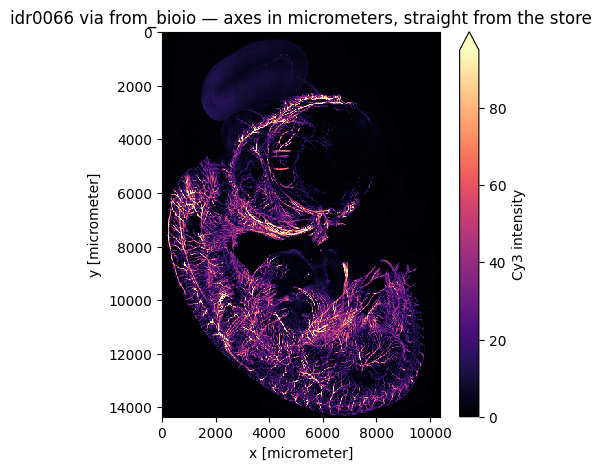

In [5]:
# What from_bioio actually changed: it promoted the metadata into real COORDINATES + indexes
# (and clean dims) — not just a metadata blob. The `ome` carrier in attrs is a separate thing:
# the verbatim block kept for lossless round-trip (and for fields with no axis here, e.g. the
# Cy3 channel — this store is 2-D with no `c` dim, so it surfaces via .ngff.channels).
print("bioio     :", tuple(flat.dims), "coords", list(flat.coords), "indexes", list(flat.xindexes))
print("from_bioio:", tuple(restored.dims), "coords", list(restored.coords),
      "indexes", {k: type(v).__name__ for k, v in restored.xindexes.items()})
print("  y =", restored["y"].values[:3], "… µm", restored["y"].attrs)
print("  channels (from carrier, no c axis):", [c.label for c in restored.ngff.channels])
# The payoff of real coords: physical selection in microns — impossible on bioio's flat array.
print("  restored.sel(x=2000:4000 µm, y=3000:5000 µm) ->",
      dict(restored["image"].sel(x=slice(2000, 4000), y=slice(3000, 5000)).sizes))

# Downsampled preview off a coarse pyramid level; xarray labels the axes in microns for free.
preview = from_bioio(BioImage(url_2d), resolution=4)["image"]
preview.plot(size=5, cmap="magma", vmax=float(np.percentile(preview.values, 99.5)),
             cbar_kwargs={"label": f"{restored.ngff.channels[0].label} intensity"})
plt.gca().set_aspect("equal"); plt.gca().invert_yaxis()
plt.title("idr0066 via from_bioio — axes in micrometers, straight from the store")
plt.show()

**And a format the `ome-zarr` engine can't open — OME-TIFF.** `bioio` reads it and hands back
a lazy xarray with the dims, channels, and pixel sizes it parsed.

> **One reader, hundreds of formats — all arriving as xarray.** *(Full metadata re-imposition is adapter tier-2, on the roadmap.)*

In [5]:
import tempfile, os, tifffile

# A synthetic 2-channel OME-TIFF with physical pixel size + channel names baked into OME-XML.
yy, xx = np.mgrid[0:256, 0:256]
ch0 = (np.exp(-(((xx-90)**2 + (yy-120)**2) / 1800)) * 255).astype("uint8")
ch1 = (np.exp(-(((xx-170)**2 + (yy-150)**2) / 2600)) * 255).astype("uint8")
tif_path = os.path.join(tempfile.mkdtemp(), "cells.ome.tif")
tifffile.imwrite(tif_path, np.stack([ch0, ch1]), photometric="minisblack",
    metadata={"axes": "CYX", "PhysicalSizeX": 0.325, "PhysicalSizeXUnit": "µm",
              "PhysicalSizeY": 0.325, "PhysicalSizeYUnit": "µm",
              "Channel": {"Name": ["GFP", "RFP"]}})

# The `ome-zarr` engine reads OME-Zarr stores, not arbitrary image formats:
try:
    xr.open_dataset(tif_path, engine="ome-zarr")
except Exception as e:
    print("engine='ome-zarr':", type(e).__name__, "— not an OME-Zarr store")

# bioio opens the OME-TIFF and parses the OME-XML metadata into an xarray:
tiff_img = BioImage(tif_path)
print("bioio       :", tiff_img.xarray_dask_data.dims, tiff_img.xarray_dask_data.shape)
print("pixel size  :", tiff_img.physical_pixel_sizes)
print("channels    :", [str(c) for c in tiff_img.channel_names])

engine='ome-zarr': GroupNotFoundError — not an OME-Zarr store
bioio       : ('T', 'C', 'Z', 'Y', 'X') (1, 2, 1, 256, 256)
pixel size  : PhysicalPixelSizes(Z=None, Y=0.325, X=0.325)
channels    : ['GFP', 'RFP']


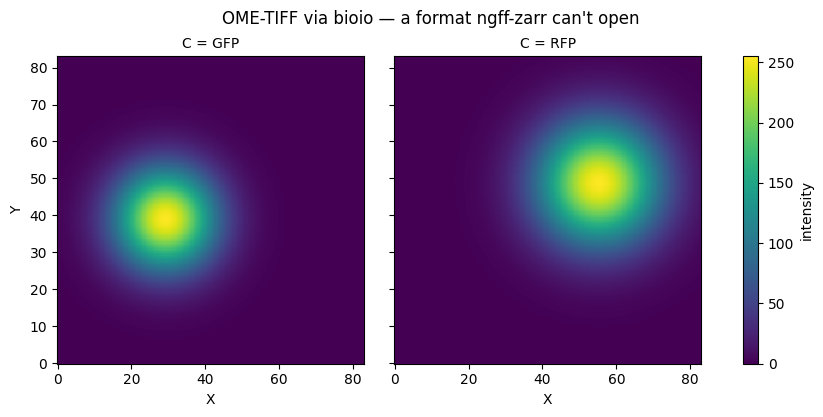

In [6]:
# bioio's xarray: usable immediately with named dims + lazy dask, even for a non-zarr format.
tiff_xr = tiff_img.xarray_dask_data.isel(T=0, Z=0).rename("intensity")   # (C, Y, X), C=['GFP','RFP']
fg = tiff_xr.plot(col="C", cmap="viridis", size=4)
for ax in fg.axs.flat:
    ax.set_aspect("equal")
fg.fig.suptitle("OME-TIFF via bioio — a format ngff-zarr can't open", y=1.03)
plt.show()

In [7]:
import tempfile, os, tifffile

# A synthetic 2-channel OME-TIFF with physical pixel size + channel names baked into OME-XML.
yy, xx = np.mgrid[0:256, 0:256]
ch0 = (np.exp(-(((xx-90)**2 + (yy-120)**2) / 1800)) * 255).astype("uint8")
ch1 = (np.exp(-(((xx-170)**2 + (yy-150)**2) / 2600)) * 255).astype("uint8")
tif_path = os.path.join(tempfile.mkdtemp(), "cells.ome.tif")
tifffile.imwrite(tif_path, np.stack([ch0, ch1]), photometric="minisblack",
    metadata={"axes": "CYX", "PhysicalSizeX": 0.325, "PhysicalSizeXUnit": "µm",
              "PhysicalSizeY": 0.325, "PhysicalSizeYUnit": "µm",
              "Channel": {"Name": ["GFP", "RFP"]}})

# ngff-zarr / the ome-zarr engine only speak zarr:
try:
    xarray_ngff.open_ngff_dataset(tif_path)
except Exception as e:
    print("ngff-zarr :", type(e).__name__, "- can't read a TIFF")

# bioio reads it and parses the OME-XML metadata:
tiff_img = BioImage(tif_path)
print("bioio     :", tiff_img.xarray_dask_data.dims, tiff_img.xarray_dask_data.shape)
print("pixel size:", tiff_img.physical_pixel_sizes)
print("channels  :", [str(c) for c in tiff_img.channel_names])

ngff-zarr : ValueError - can't read a TIFF
bioio     : ('T', 'C', 'Z', 'Y', 'X') (1, 2, 1, 256, 256)
pixel size: PhysicalPixelSizes(Z=None, Y=0.325, X=0.325)
channels  : ['GFP', 'RFP']


## 2. Named dimensions & selection in physical units

> **Select by meaning, not bookkeeping:** `c="Dapi"`, `x=slice(20, 75)` microns — no axis order to remember, no pixel arithmetic.

The `.ngff` accessor exposes the OME metadata as typed attributes. We'll use a multi-channel
z-stack from IDR (`idr0062A`).

In [6]:
url_stack = "https://uk1s3.embassy.ebi.ac.uk/idr/zarr/v0.4/idr0062A/6001240.zarr"
stack = xarray_ngff.open_ngff_datatree(url_stack)

# The `.ngff` accessor exposes the OME metadata as typed attributes (not raw dicts):
print("version :", stack.ngff.version)
print("axes    :", [f"{a.name} ({a.type}, {a.unit})" for a in stack.ngff.axes])
print("channels:", [c.label for c in stack.ngff.channels])

img = stack["0"].to_dataset()["image"]   # dims carry real names: (c, z, y, x)
img

version : 0.4
axes    : ['c (channel, None)', 'z (space, micrometer)', 'y (space, micrometer)', 'x (space, micrometer)']
channels: ['LaminB1', 'Dapi']


<xarray.DataArray 'image' (c: 2, z: 236, y: 275, x: 271)> Size: 70MB
dask.array<chunksize=(1, 1, 275, 271), meta=np.ndarray>
Coordinates:
  * c        (c) object 16B 'LaminB1' 'Dapi'
  * z        (z) float64 2kB 0.0 0.5002 1.0 1.501 ... 116.0 116.5 117.0 117.5
  * y        (y) float64 2kB 0.0 0.3604 0.7208 1.081 ... 97.67 98.03 98.39 98.75
  * x        (x) float64 2kB 0.0 0.3604 0.7208 1.081 ... 96.23 96.59 96.95 97.31
Indexes:
    z        TransformIndex
    y        TransformIndex
    x        TransformIndex

In [7]:
stack["0"].to_dataset().ngff

axis,type,unit,transform,extent (world)
c,channel,pixel/index ·,—,—
z,space,micrometer,"scale 0.500203, +0",0 … 117.548
y,space,micrometer,"scale 0.360398, +0",0 … 98.7491
x,space,micrometer,"scale 0.360398, +0",0 … 97.3075


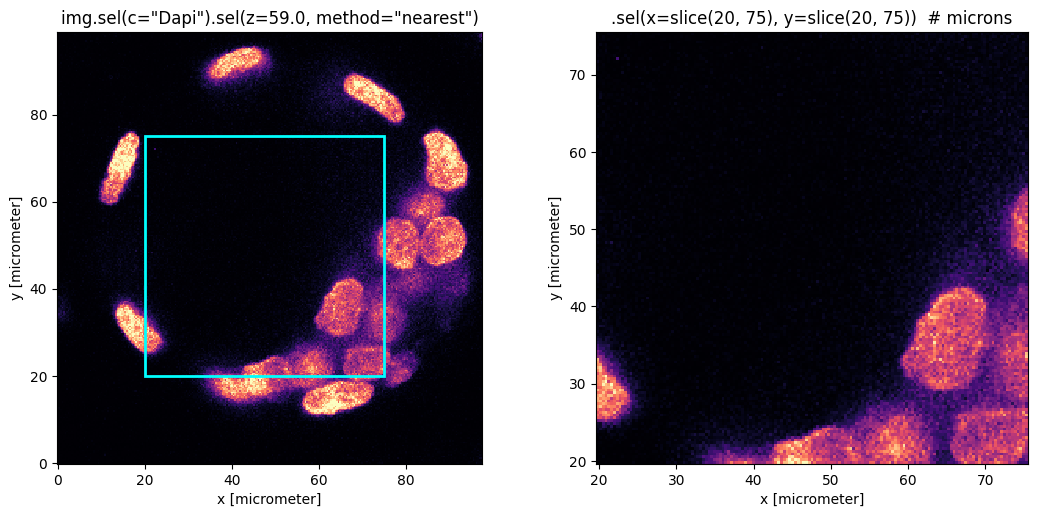

In [10]:
# Select by NAME and by PHYSICAL POSITION — no axis-order bookkeeping, no pixel math.
plane = img.sel(c="Dapi").sel(z=59.0, method="nearest")     # channel by label, z in microns
roi = plane.sel(x=slice(20, 75), y=slice(20, 75))           # a 55 x 55 micron window

vmax = float(np.percentile(plane, 99.5))
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 5.2))
plane.plot(ax=a0, cmap="magma", vmax=vmax, add_colorbar=False)
a0.add_patch(plt.Rectangle((20, 20), 55, 55, fill=False, ec="cyan", lw=2))
a0.set(title='img.sel(c="Dapi").sel(z=59.0, method="nearest")', aspect="equal")
roi.plot(ax=a1, cmap="magma", vmax=vmax, add_colorbar=False)
a1.set(title=".sel(x=slice(20, 75), y=slice(20, 75))  # microns", aspect="equal")
fig.tight_layout(); plt.show()

### Aside — units live in coordinate *attrs*, not `pint` (an honest tension)

`x`/`y` carry `units="micrometer"` as a CF-style coordinate **attribute** (surfaced, typed, via
`.ngff.units`), *not* as `pint` quantities. It's tempting to `pint.quantify()` so units become
first-class — but that fights the two things this design is built on:

- it **replaces the lazy `TransformIndex` with a `PintIndex`** and materialises the coordinate,
  losing the compute-on-demand coords;
- it **breaks plain `.sel(x=2000)`** — selection then needs unit-tagged labels.

CF attrs also round-trip losslessly to the NGFF axis `unit` field. So units-as-attrs + a typed
accessor is the default; a `pint` bridge would be *opt-in*. Run the next cell to see it live.

In [11]:
import importlib.util as _u

demo = from_bioio(BioImage(url_2d), resolution=5)   # small level; fast
print("stored : x index =", type(demo.xindexes["x"]).__name__,
      "| units attr =", demo["x"].attrs.get("units"), "| .ngff.units =", demo.ngff.units)

if _u.find_spec("pint_xarray"):
    import pint_xarray  # noqa: F401  (registers the .pint accessor)
    q = demo.pint.quantify()
    print("quantify: x index =", type(q.xindexes["x"]).__name__,
          "-> lazy TransformIndex replaced, coord materialised")
    try:
        q["image"].sel(x=slice(2000, 4000))
    except Exception as e:
        print("quantify: q.sel(x=2000:4000) ->", type(e).__name__,
              "- plain .sel broke (now wants unit-tagged labels)")
else:
    print("(pip install pint-xarray to see quantify() swap the index + break plain .sel)")

stored : x index = TransformIndex | units attr = micrometer | .ngff.units = {'y': 'micrometer', 'x': 'micrometer'}
quantify: x index = PintIndex -> lazy TransformIndex replaced, coord materialised
quantify: q.sel(x=2000:4000) -> PintExceptionGroup - plain .sel broke (now wants unit-tagged labels)


## 3. Multiscale pyramids as one lazy DataTree

> **One tree, every zoom on the same physical grid — and nothing loads until you compute.** A micrometer ROI means the same thing at every level.

In [12]:
stack.ngff

axis,type,unit
c,channel,pixel/index ·
z,space,micrometer
y,space,micrometer
x,space,micrometer


level 0: {'c': 2, 'z': 236, 'y': 275, 'x': 271}     70.4 MB   (lazy dask array)
level 1: {'c': 2, 'z': 236, 'y': 137, 'x': 135}     17.5 MB   (lazy dask array)
level 2: {'c': 2, 'z': 236, 'y': 68, 'x': 67}      4.3 MB   (lazy dask array)


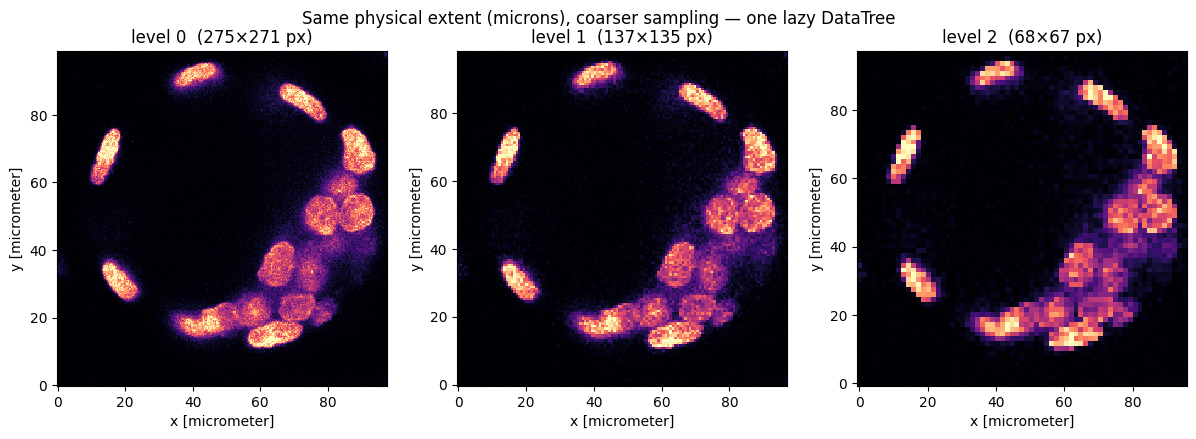

In [13]:
# Nothing below reads pixels until we plot. Each level is the same scene, coarser sampling.
for lvl in stack.ngff.levels:
    d = stack[lvl].to_dataset()["image"]
    print(f"level {lvl}: {dict(d.sizes)}   {d.data.nbytes/1e6:6.1f} MB   (lazy {type(d.data).__module__.split('.')[0]} array)")

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), constrained_layout=True)
for lvl, ax in zip(stack.ngff.levels, axes):
    d = stack[lvl].to_dataset()["image"].sel(c="Dapi").sel(z=59.0, method="nearest")
    d.plot(ax=ax, cmap="magma", vmax=float(np.percentile(d, 99.5)), add_colorbar=False)
    ax.set(title=f"level {lvl}  ({d.sizes['y']}×{d.sizes['x']} px)", aspect="equal")
fig.suptitle("Same physical extent (microns), coarser sampling — one lazy DataTree")
plt.show()

## 4. Analysis in one line

> **The standard microscopy moves are one-liners that keep their labels:** `.max("z")`, `.mean(["y","x"])`, faceting with `col="c"` — results stay in microns and channel names.

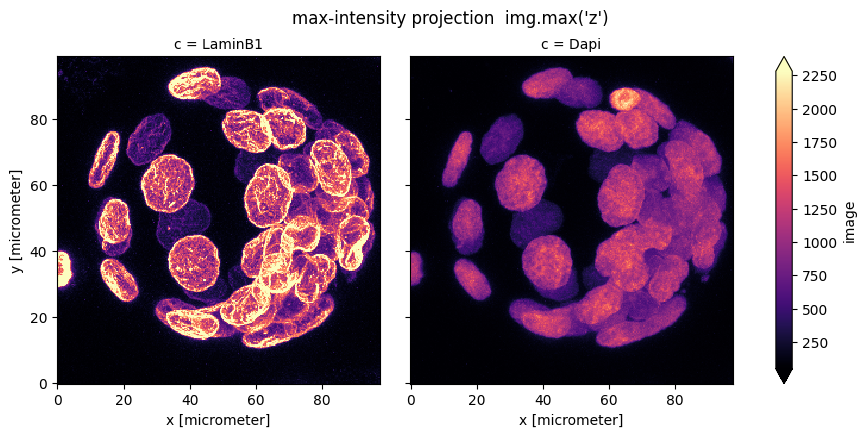

In [14]:
# Maximum-intensity projection along z (microns), one panel per channel — the labels ride along.
mip = img.max("z")                      # (c, z, y, x) -> (c, y, x); c stays ['LaminB1','Dapi']
fg = mip.plot(col="c", cmap="magma", robust=True, size=4.2)
for ax in fg.axs.flat:
    ax.set_aspect("equal")
fg.fig.suptitle("max-intensity projection  img.max('z')", y=1.03)
plt.show()

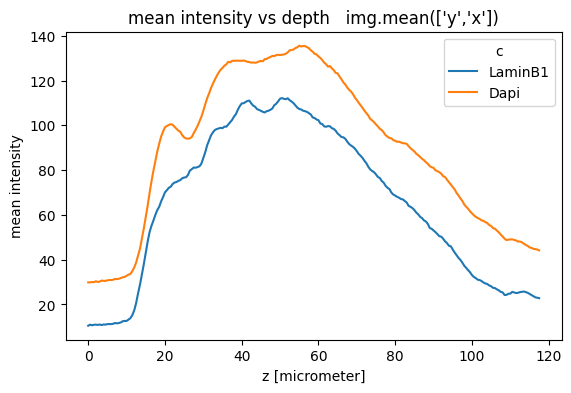

In [15]:
# A depth profile: mean intensity vs z. The reduction keeps z as a physical (micron) axis.
profile = img.mean(["y", "x"])          # (c, z); z is still in microns
profile.plot.line(x="z", hue="c", size=4, aspect=1.6)
plt.title("mean intensity vs depth   img.mean(['y','x'])")
plt.ylabel("mean intensity"); plt.show()

## 5. Lens distortion correction

A lens bends a straight scene into a curved photo, so a pixel's physical location needs full
2-D world coordinates `x(y, x)`, `y(y, x)`.

> **xarray carries those curved coordinates, so `.sel` works in physical space directly on the raw, distorted image.**

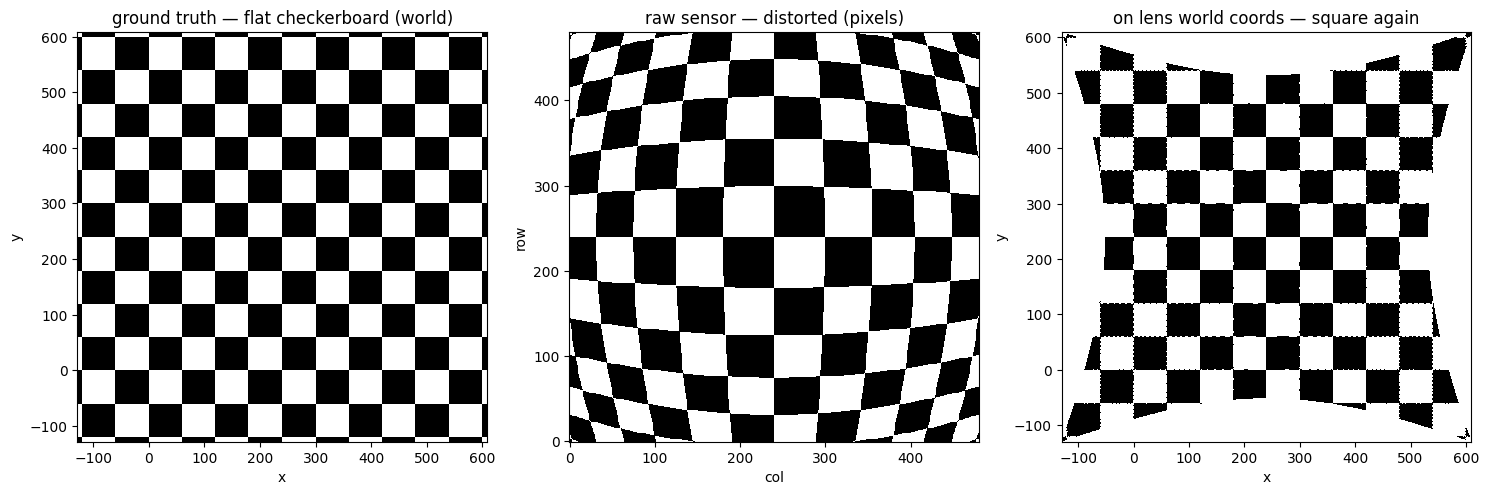

In [16]:
import warnings
from xarray.indexes import CoordinateTransform
from xarray_ngff.indexes import TransformIndex

class DivisionLens(CoordinateTransform):
    """Invertible radial lens (division model): world_r = pixel_r / (1 - k·pixel_r²).
    Closed-form BOTH ways — so `.sel` (world → pixel) is *exact*, no tree."""
    def __init__(self, width, height, k):
        super().__init__(["x", "y"], {"y": height, "x": width})
        self.w, self.h, self.k = width, height, k
        self.cx, self.cy, self.f = (width - 1) / 2, (height - 1) / 2, np.hypot(width, height) / 2
    def forward(self, dp):                                    # pixel → world
        xn = (np.asarray(dp["x"], float) - self.cx) / self.f
        yn = (np.asarray(dp["y"], float) - self.cy) / self.f
        d = 1 / (1 - self.k * (xn**2 + yn**2))
        return {"x": self.cx + self.f * d * xn, "y": self.cy + self.f * d * yn}
    def reverse(self, cl):                                    # world → pixel (closed form)
        xw = (np.asarray(cl["x"], float) - self.cx) / self.f
        yw = (np.asarray(cl["y"], float) - self.cy) / self.f
        rw = np.hypot(xw, yw)
        with np.errstate(divide="ignore", invalid="ignore"):
            pr = (-1 + np.sqrt(1 + 4 * self.k * rw**2)) / (2 * self.k * rw)
            s = np.where(rw > 0, pr / rw, 1.0)
        return {"x": self.cx + self.f * (xw * s), "y": self.cy + self.f * (yw * s)}
    def equals(self, other, **kw):
        return isinstance(other, DivisionLens) and (self.w, self.h, self.k) == (other.w, other.h, other.k)

H = W = 481
SQ = 60.0
checker = lambda a, b: ((np.floor(a / SQ) + np.floor(b / SQ)) % 2).astype(float)

lens = DivisionLens(W, H, k=0.35)
co = xr.Coordinates.from_xindex(TransformIndex(lens))     # lazy world coords + EXACT .sel
X, Y = np.asarray(co["x"]), np.asarray(co["y"])
scene = checker(X, Y)                                     # flat checker seen through the lens
iy, ix = np.mgrid[0:H, 0:W]
da = xr.DataArray(scene, coords=co, dims=("y", "x")).assign_coords(
    row=(("y", "x"), iy), col=(("y", "x"), ix))

xlo, xhi, ylo, yhi = X.min(), X.max(), Y.min(), Y.max()
truth = checker(*np.meshgrid(np.linspace(xlo, xhi, W), np.linspace(ylo, yhi, H)))

fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(15, 5))
a0.imshow(truth, origin="lower", cmap="gray", extent=[xlo, xhi, ylo, yhi], interpolation="nearest")
a0.set(title="ground truth — flat checkerboard (world)", xlabel="x", ylabel="y", aspect="equal")
a1.imshow(scene, origin="lower", cmap="gray", interpolation="nearest")
a1.set(title="raw sensor — distorted (pixels)", xlabel="col", ylabel="row")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    a2.pcolormesh(da["x"], da["y"], da, shading="nearest", cmap="gray")
a2.set(title="on lens world coords — square again", xlabel="x", ylabel="y", aspect="equal")
fig.tight_layout(); plt.show()

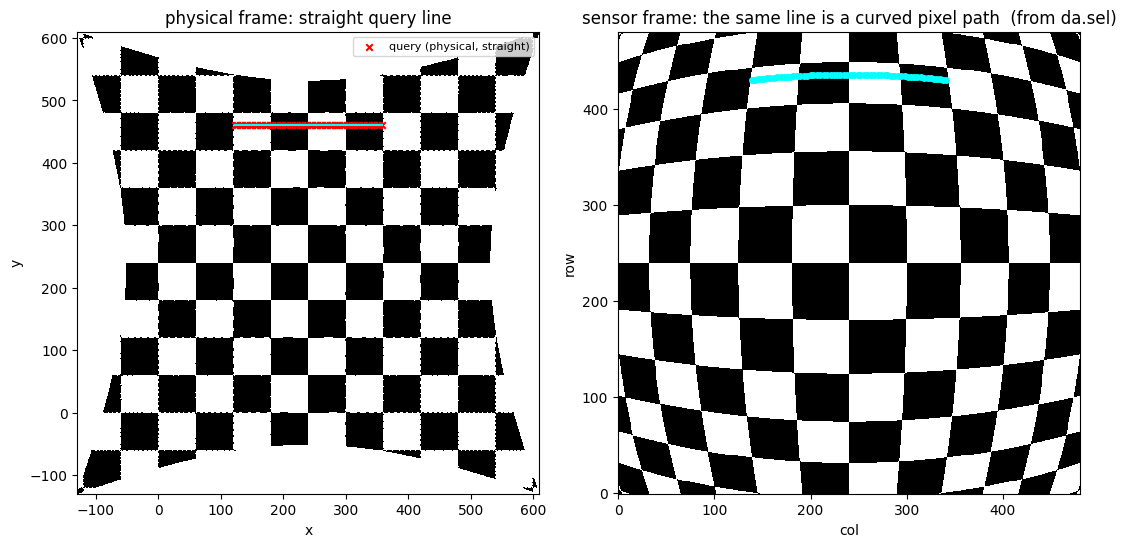

In [17]:
# A STRAIGHT line in physical space maps to a curved set of pixels — resolved by .sel.
# With the invertible model this is EXACT (closed-form world→pixel), not a nearest guess.
xlo, xhi = float(da["x"].min()), float(da["x"].max())
ylo, yhi = float(da["y"].min()), float(da["y"].max())
qx = np.linspace(xlo + 0.34 * (xhi - xlo), xhi - 0.34 * (xhi - xlo), 60)
qy = np.full_like(qx, ylo + 0.80 * (yhi - ylo))
picked = da.sel(x=xr.DataArray(qx, dims="p"), y=xr.DataArray(qy, dims="p"), method="nearest")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 5.4))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    a0.pcolormesh(da["x"], da["y"], da, shading="nearest", cmap="gray")
a0.plot(qx, qy, "-", color="cyan", lw=1.5)
a0.scatter(qx, qy, c="red", marker="x", s=22, label="query (physical, straight)")
a0.set(title="physical frame: straight query line", xlabel="x", ylabel="y", aspect="equal")
a0.legend(loc="upper right", fontsize=8)
a1.imshow(scene, origin="lower", cmap="gray", interpolation="nearest")
a1.plot(picked["col"], picked["row"], "-o", color="cyan", ms=4, lw=1.5)
a1.set(title="sensor frame: the same line is a curved pixel path  (from da.sel)",
       xlabel="col", ylabel="row")
fig.tight_layout(); plt.show()

And here's why it matters for *analysis*. Read the brightness along a line: selecting a
straight line in **world** space (`.sel`) samples the flat scene evenly — a clean square wave.
Naively taking a straight line in **pixel** space (`.isel` a row) samples the *distorted*
image, so the bands warp with the lens. Same request, wrong answer if you ignore the geometry.

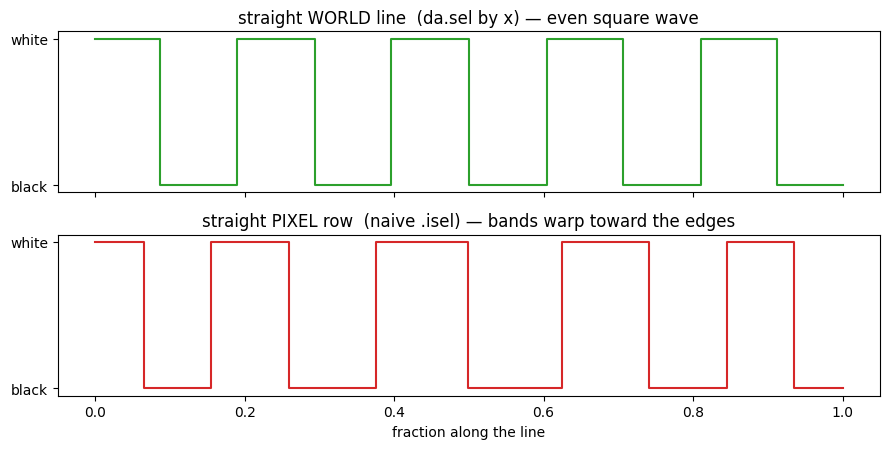

In [18]:
# Read brightness along a line. A straight WORLD line (.sel by x) samples the flat scene
# evenly; a straight PIXEL row (.isel) samples the distorted image, so bands warp.
cy = (H - 1) / 2                                             # centre row
wl = float(lens.forward({"x": np.array([0.0]), "y": np.array([cy])})["x"][0])
wr = float(lens.forward({"x": np.array([W - 1.0]), "y": np.array([cy])})["x"][0])
xs = np.linspace(wl, wr, 500)                               # exactly the imaged extent of that row
world_line = da.sel(x=xr.DataArray(xs, dims="s"),
                    y=xr.DataArray(np.full(xs.size, cy), dims="s"), method="nearest")
pixel_row = da.isel(y=H // 2).values

fig, (a0, a1) = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True)
a0.step(np.linspace(0, 1, world_line.sizes["s"]), world_line.values, where="mid", color="tab:green")
a0.set(title="straight WORLD line  (da.sel by x) — even square wave")
a1.step(np.linspace(0, 1, W), pixel_row, where="mid", color="tab:red")
a1.set(title="straight PIXEL row  (naive .isel) — bands warp toward the edges",
       xlabel="fraction along the line")
for a in (a0, a1):
    a.set_yticks([0, 1]); a.set_yticklabels(["black", "white"])
fig.tight_layout(); plt.show()

## 6. Reassembling images from transforms — mosaic stitching

> **Give each tile its `translation` and they all land on one shared world grid** — ordinary xarray alignment reassembles the mosaic, and plain `.sel` resolves any point, even across seams. No custom index.

tile_00: shape=(300, 300)  translation={'y': 0.0, 'x': 0.0}
tile_01: shape=(300, 300)  translation={'y': 0.0, 'x': 212.0}
tile_10: shape=(300, 300)  translation={'y': 212.0, 'x': 0.0}
tile_11: shape=(300, 300)  translation={'y': 212.0, 'x': 212.0}
mosaic world bounds: {'y': (0.0, 512.0), 'x': (0.0, 512.0)}


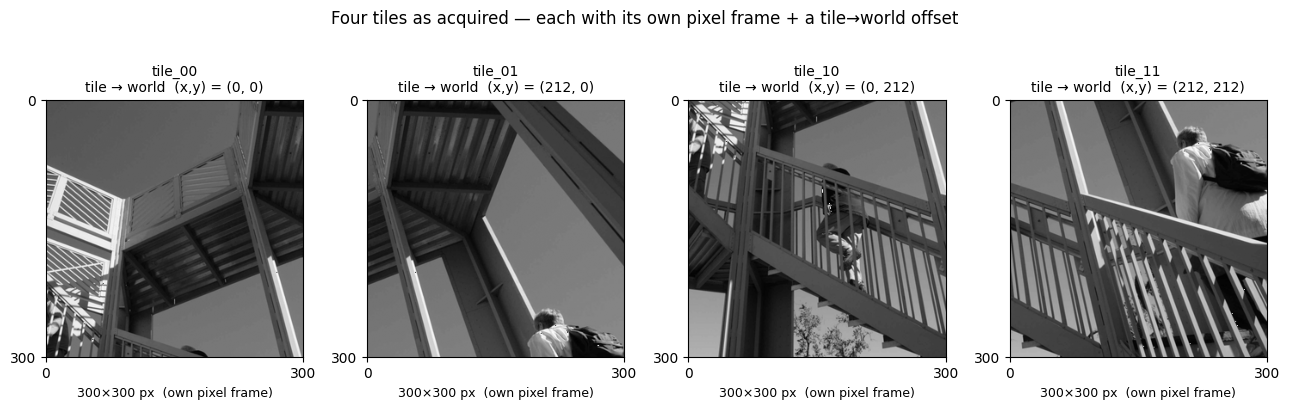

In [19]:
from scipy.datasets import ascent   # a recognizable 512x512 photo

# Acquire it as four overlapping tiles — each just a raw array plus its own world offset.
full = ascent().astype(float)
th = tw = 300
offsets = {"tile_00": (0, 0), "tile_01": (0, 212), "tile_10": (212, 0), "tile_11": (212, 212)}
tiles = [Tile(name=n, data=full[ty:ty+th, tx:tx+tw], dims=("y", "x"),
              translation={"y": float(ty), "x": float(tx)})
         for n, (ty, tx) in offsets.items()]

for t in tiles:
    print(f"{t.name}: shape={t.data.shape}  translation={t.translation}")
print("mosaic world bounds:", mosaic_bounds(tiles))

# Each tile is indexed from its OWN (0,0); the `translation` says where it belongs in the world.
fig, axes = plt.subplots(1, 4, figsize=(13, 3.8))
for ax, t in zip(axes, tiles):
    ax.imshow(t.data, cmap="gray", extent=[0, t.data.shape[1], t.data.shape[0], 0])
    ax.set_title(f"{t.name}\ntile → world  (x,y) = ({t.translation['x']:.0f}, {t.translation['y']:.0f})",
                 fontsize=10)
    ax.set_xlabel(f"{t.data.shape[1]}×{t.data.shape[0]} px  (own pixel frame)", fontsize=9)
    ax.set_xticks([0, t.data.shape[1]]); ax.set_yticks([0, t.data.shape[0]])
fig.suptitle("Four tiles as acquired — each with its own pixel frame + a tile→world offset", y=1.04)
fig.tight_layout(); plt.show()

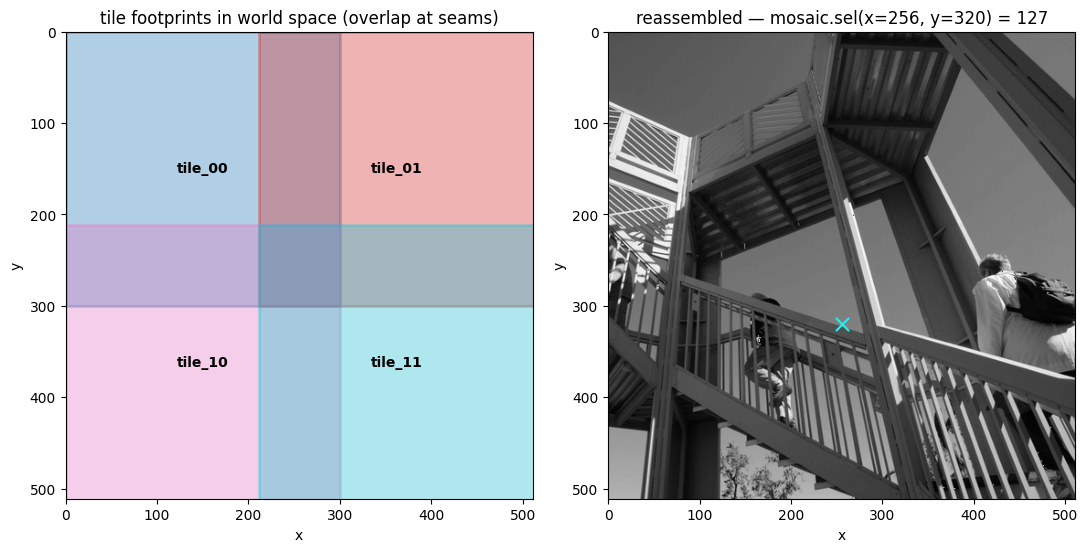

In [20]:
placed = place_tiles(tiles)      # each tile -> shared world coords (phys = pixel + offset)

# Reassemble by ordinary label-based assignment onto one shared world grid.
b = mosaic_bounds(tiles)
gy = np.arange(int(b["y"][1])); gx = np.arange(int(b["x"][1]))
mosaic = xr.DataArray(np.full((gy.size, gx.size), np.nan),
                      coords={"y": gy, "x": gx}, dims=("y", "x"))
for da_t in placed.values():
    mosaic.loc[{"y": da_t["y"].values, "x": da_t["x"].values}] = da_t.values

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 5.6))
colors = plt.cm.tab10(np.linspace(0, 1, len(tiles)))
for t, c in zip(tiles, colors):
    x0, y0 = t.translation["x"], t.translation["y"]; h, w = t.data.shape
    a0.add_patch(plt.Rectangle((x0, y0), w, h, facecolor=c, edgecolor=c, alpha=0.35, lw=2))
    a0.text(x0 + w/2, y0 + h/2, t.name, ha="center", va="center", fontweight="bold")
a0.set(title="tile footprints in world space (overlap at seams)",
       xlim=(0, gx[-1]), ylim=(0, gy[-1]), aspect="equal", xlabel="x", ylabel="y")
a0.invert_yaxis()
a1.imshow(mosaic, cmap="gray", extent=[0, gx[-1], gy[-1], 0])
qx, qy = 256.0, 320.0                            # a point in the overlap region
val = float(mosaic.sel(x=qx, y=qy, method="nearest"))   # plain .sel, resolves across seams
a1.scatter([qx], [qy], c="cyan", marker="x", s=90)
a1.set(title=f"reassembled — mosaic.sel(x={qx:.0f}, y={qy:.0f}) = {val:.0f}",
       aspect="equal", xlabel="x", ylabel="y")
fig.tight_layout(); plt.show()

In [ ]:
# "Which pixel is at world (x, y)?" For a translated tile it's just a subtraction
# (translation is separable + invertible) — and since tiles overlap, a seam point
# lands in more than one tile.
def locate(wx, wy):
    for t in tiles:
        x0, y0 = t.translation["x"], t.translation["y"]
        h, w = t.data.shape
        if x0 <= wx < x0 + w and y0 <= wy < y0 + h:
            yield f"{t.name}[row={int(round(wy - y0))}, col={int(round(wx - x0))}]"

for wx, wy in [(120.0, 90.0), (256.0, 256.0), (400.0, 300.0)]:
    hits = list(locate(wx, wy))
    print(f"world (x={wx:.0f}, y={wy:.0f}) -> " + (", ".join(hits) if hits else "(outside mosaic)"))

## 7. Deskewing with an affine transform

Light-sheet / SCAPE deskew is a **shear** — non-separable (physical `y` couples to *both*
pixel `z` and `y`), but a plain affine.

> **`AffineTransform` carries the matrix and its exact inverse, so the raw skewed stack reads out on a regular physical grid and `.sel` on it is exact.**

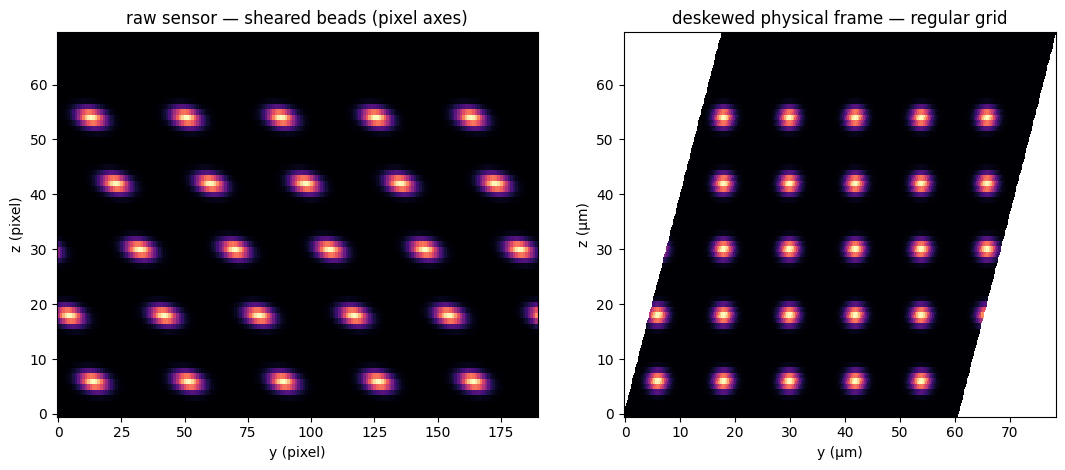

In [21]:
from xarray_ngff.indexes import TransformIndex

nz, ny = 70, 190
shear = 0.8
# world = A @ pixel, with A = (z,y scaling) @ (shear): y_um mixes pixel z and y -> a shear.
A = np.diag([1.0, 0.32]) @ np.array([[1.0, 0.0], [shear, 1.0]])
deskew = AffineTransform(A, coord_names=["z_um", "y_um"], dims=["z", "y"],
                         dim_sizes={"z": nz, "y": ny})
coords = xr.Coordinates.from_xindex(TransformIndex(deskew))   # exact-inverse .sel, no tree
Zw, Yw = np.asarray(coords["z_um"]), np.asarray(coords["y_um"])

# Fluorescent beads on a regular grid in PHYSICAL space -> sheared on the raw sensor.
scene = np.zeros((nz, ny))
for z0 in np.arange(6, Zw.max() - 3, 12):
    for y0 in np.arange(6, Yw.max() - 3, 12):
        scene += np.exp(-(((Zw - z0) ** 2) / 3 + ((Yw - y0) ** 2) / 3))
zz, yy = np.mgrid[0:nz, 0:ny]
da = xr.DataArray(scene, coords=coords, dims=("z", "y")).assign_coords(
    zpix=(("z", "y"), zz), ypix=(("z", "y"), yy))

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4.8))
a0.imshow(scene, origin="lower", cmap="magma", aspect="auto", interpolation="nearest")
a0.set(title="raw sensor — sheared beads (pixel axes)", xlabel="y (pixel)", ylabel="z (pixel)")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    a1.pcolormesh(da["y_um"], da["z_um"], da, shading="nearest", cmap="magma")
a1.set(title="deskewed physical frame — regular grid", xlabel="y (µm)", ylabel="z (µm)")
a1.set_aspect("equal")
fig.tight_layout(); plt.show()

In [22]:
# Because the inverse is a matrix (not a tree search), selection is exact.
p = {"z": np.array([30.0]), "y": np.array([120.0])}
back = deskew.reverse(deskew.forward(p))
resid = max(abs(back["z"][0] - 30.0), abs(back["y"][0] - 120.0))
print(f"pixel -> world -> pixel round-trip residual: {resid:.1e}  (exact matrix inverse)")

# Physical selection in microns, plain scalars — resolved through A^-1, no KD-tree:
pt = da.sel(z_um=42.0, y_um=54.0, method="nearest")
print(f"da.sel(z_um=42, y_um=54) -> pixel (z={int(pt.zpix)}, y={int(pt.ypix)}), value {float(pt):.2f}")

pixel -> world -> pixel round-trip residual: 0.0e+00  (exact matrix inverse)
da.sel(z_um=42, y_um=54) -> pixel (z=42, y=135), value 1.00


## Takeaways

- **Metadata survives.** Real axis names, physical coordinates + units, channel labels, and the verbatim NGFF carrier — losslessly, whether the bytes came from an OME-Zarr store or through `bioio`.
- **Select by meaning.** `.sel(c="Dapi", x=slice(20, 75))` — channel names and microns, not pixel indices. The same physical ROI resolves at every pyramid level, and it's all lazy until you compute.
- **Analysis carries the labels.** `.max("z")`, `.mean(["y","x"])`, `col="c"` — the standard microscopy moves stay one-liners with physical axes intact.
- **Hard geometry is just coordinates.** Lens distortion (no inverse → KD-tree, *nearest sampled*) and deskew (exact matrix inverse) are both `.sel`; a translated mosaic reassembles with plain coordinate alignment — no custom index at all.